# Biomarker discovery — univariate AUC + multivariate panel

Clinical metabolomics studies typically end with a biomarker question:
*can a small set of metabolites separate cases from controls?* Two
functions address this:

- **`ov.metabol.roc_feature`** — per-feature AUC (polarity-invariant,
  so you don't need to know *a priori* which direction each metabolite
  should change). Optional bootstrap 95% CI.
- **`ov.metabol.biomarker_panel`** — nested cross-validation of a
  multi-metabolite panel with RF / logistic regression / SVM. Reports
  per-fold AUC, feature importance, and an optional permutation null
  p-value.

We use the MetaboAnalyst **Cachexia** dataset (77 samples × 63 urinary
metabolites, binary `Muscle loss` label).


## 0 — Setup and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import omicverse as ov

csv_path = ov.datasets.download_data(
    url='https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv',
    file_path='human_cachexia.csv',
    dir='metabol_demo',
)
adata = ov.metabol.read_metaboanalyst(csv_path, group_col='Muscle loss')
adata = ov.metabol.impute(adata, method='qrilc', seed=0)
adata = ov.metabol.normalize(adata, method='pqn')
adata = ov.metabol.transform(adata, method='log')
adata


/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔍 Downloading data to metabol_demo/human_cachexia.csv
⚠️ File metabol_demo/human_cachexia.csv already exists


AnnData object with n_obs × n_vars = 77 × 63
    obs: 'group'
    var: 'missing_frac'
    uns: 'metabol'
    layers: 'raw'

## 1 — Per-feature ROC AUC

`roc_feature` returns a sorted DataFrame of AUC per metabolite. With
`ci=True` it adds 95% bootstrap CIs (slower).


In [2]:
auc = ov.metabol.roc_feature(
    adata,
    group_col='group',
    pos_group='cachexic',
    neg_group='control',
    ci=True, n_bootstrap=500, seed=0,
)
auc.head(15)


                          auc    ci_low   ci_high
Isoleucine           0.724823  0.604165  0.831538
Uracil               0.720922  0.602093  0.826518
Creatine             0.705674  0.584924  0.815645
Acetone              0.679433  0.547649  0.795713
Pantothenate         0.676596  0.559742  0.781275
Succinate            0.669504  0.533756  0.797196
Glucose              0.658156  0.542094  0.769908
N,N-Dimethylglycine  0.656028  0.532805  0.774316
Methylguanidine      0.651773  0.527971  0.773909
Glutamine            0.641844  0.523199  0.775583
Hypoxanthine         0.637589  0.512414  0.764835
Alanine              0.636879  0.516322  0.762654
Tartrate             0.627660  0.516927  0.751250
cis-Aconitate        0.624113  0.514316  0.754925
Betaine              0.621631  0.509081  0.752555

### AUC distribution

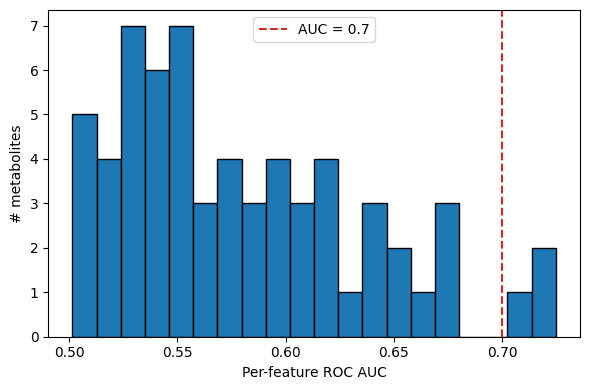

3 metabolites with AUC >= 0.7


In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(auc['auc'], bins=20, edgecolor='k', color='C0')
ax.axvline(0.7, color='C3', ls='--', label='AUC = 0.7')
ax.set_xlabel('Per-feature ROC AUC')
ax.set_ylabel('# metabolites')
ax.legend()
fig.tight_layout()
plt.show()
print(f'{(auc["auc"] >= 0.7).sum()} metabolites with AUC >= 0.7')


## 2 — Multi-metabolite panel with nested CV

`biomarker_panel` runs 5-outer × 3-inner nested CV. For `features=10`
it pre-screens to the top 10 by univariate AUC — note this leaks the
test fold (see docstring caveat); pass an explicit feature list from
an independent screening cohort for publication estimates.


In [4]:
panel = ov.metabol.biomarker_panel(
    adata,
    group_col='group',
    pos_group='cachexic', neg_group='control',
    features=10,
    classifier='lr',        # try 'rf' or 'svm' too
    cv_outer=5, cv_inner=3,
    n_permutations=100,     # permutation null
    seed=0,
)
print(f'Mean outer-fold AUC : {panel.mean_auc:.3f} ± {panel.std_auc:.3f}')
print(f'Permutation p-value : {panel.permutation_pvalue:.3f}')
print(f'Top features        :')
print(panel.feature_importance)


Mean outer-fold AUC : 0.843 ± 0.091
Permutation p-value : 0.010
Top features        :
Isoleucine             0.340771
Pantothenate           0.230042
Glucose                0.228501
Creatine               0.215480
Uracil                 0.202967
Succinate              0.166891
Methylguanidine        0.117726
Acetone                0.117388
Glutamine              0.116021
N,N-Dimethylglycine    0.098620
Name: importance, dtype: float64


### Per-fold AUC and feature importance

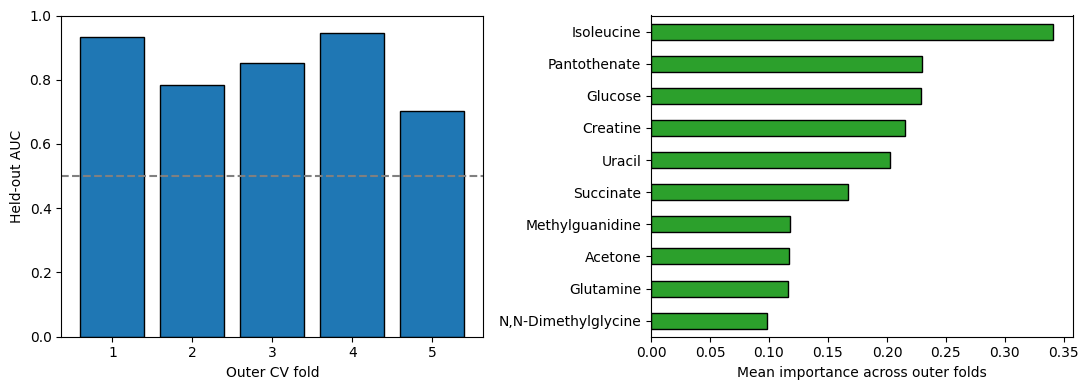

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(range(1, panel.cv_outer + 1), panel.outer_aucs,
        color='C0', edgecolor='k')
ax1.axhline(0.5, color='gray', ls='--')
ax1.set_xlabel('Outer CV fold')
ax1.set_ylabel('Held-out AUC')
ax1.set_ylim(0, 1)

panel.feature_importance.iloc[::-1].plot.barh(ax=ax2, color='C2',
                                                edgecolor='k')
ax2.set_xlabel('Mean importance across outer folds')
fig.tight_layout()
plt.show()


### Out-of-fold ROC curve for the panel

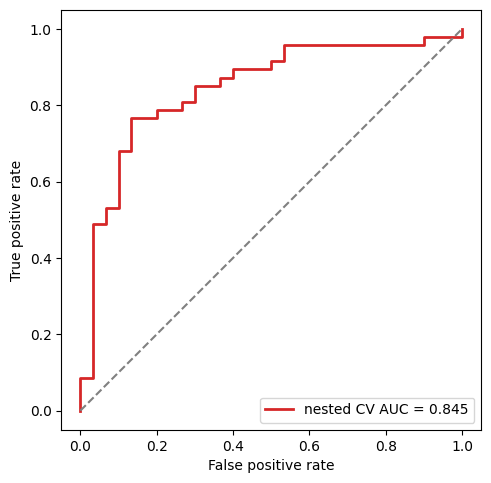

In [6]:
from sklearn.metrics import roc_curve, auc as _auc
fpr, tpr, _ = roc_curve(panel.outer_labels, panel.outer_predictions)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color='C3', lw=2,
        label=f'nested CV AUC = {_auc(fpr, tpr):.3f}')
ax.plot([0, 1], [0, 1], color='gray', ls='--')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
ax.set_aspect('equal')
fig.tight_layout()
plt.show()


## Takeaways

- Start with `roc_feature` for a quick univariate screen.
- Escalate to `biomarker_panel` to estimate the joint AUC of a small
  panel with *unbiased* nested-CV.
- The permutation p (small, here likely < 0.05) is the key sanity
  check — if it's not small your panel is overfitting noise.
